# **Ch 19. Learning Deep Learning**

## <span style="color: blue;">**1. Concepts, History, and Types of Deep Learning**</span>

## **Gemini: Explanation**

### 1. The Concept of Deep Learning

#### Definition: Representation Learning
Deep learning is a subfield of machine learning, defined as **"a technology in which machines autonomously learn latent representations of data through artificial neural networks."**

#### Core Principle: Mimicking the Brain
The human brain consists of approximately 100 billion neurons and the synapses that connect them. Deep learning models this mathematically.
* **Neuron ≈ Node:** A unit that receives and processes information.
* **Synapse ≈ Weight:** Connection strength that adjusts the importance of information. Corresponds to $w$ in $y = wx + b$.
* **Activation:** The process of transmitting a signal when a certain threshold is exceeded (activation function).

#### Traditional Machine Learning vs. Deep Learning
The most important difference is **who performs 'feature extraction.'**
* **Machine Learning (Classic ML):** Humans must manually define features. (e.g., Coding the feature "cats have pointy ears" and feeding it to the model)
* **Deep Learning:** Just feed the data and the machine discovers features on its own. (e.g., After seeing tens of thousands of photos, it learns "this pattern must be an ear") This is called **representation learning**.

---

### 2. History of Deep Learning

The history of deep learning has been a repetition of 'expectations' and 'disappointments (AI winters).' Understanding this progression is important for grasping the limitations and future directions of deep learning.

#### 1st Generation: Inception (1940s–1960s) — The Perceptron
* **1943:** Warren McCulloch and Walter Pitts proposed the first artificial neuron model.
* **1958:** Frank Rosenblatt published the **'Perceptron'** algorithm. It was a linear classifier that multiplied inputs by weights, summed them, and output 0 or 1. It received enormous attention at the time as a "thinking machine."

#### 1st AI Winter (1969) — The XOR Problem
* **1969:** Marvin Minsky and Seymour Papert mathematically proved in their book *Perceptrons* that **"a single-layer perceptron can only solve simple linear problems and can never solve nonlinear problems like XOR (exclusive OR)."**
* This led to funding cuts for neural network research, ushering in the first dark age.

### 2nd Generation: Revival (1980s) — Multi-Layer Perceptrons and Backpropagation
* **1986:** Geoffrey Hinton and colleagues rediscovered and popularized the **'backpropagation'** algorithm.
* This enabled training of **multi-layer perceptrons (MLPs)** with hidden layers. Nonlinear problems, including the XOR problem, could finally be solved.

#### 2nd AI Winter (1990s) — Vanishing Gradient and the Rise of SVM
* Problems emerged where learning failed as neural networks were stacked deeper.
    1.  **Vanishing Gradient:** During backpropagation, errors gradually approach 0 as they are transmitted to earlier layers, causing learning to stall.
    2.  **Insufficient Data and Computing Power:** Computers at the time could not handle complex computations.
* During this period, machine learning algorithms like **SVM (Support Vector Machine)** and **Random Forest**, which were mathematically elegant and performance-guaranteed, became mainstream.

### 3rd Generation: The Age of Deep Learning (2006 – Present)
* **2006:** Professor Geoffrey Hinton demonstrated the feasibility of training deep neural networks through Deep Belief Networks (DBNs), beginning to use the term 'Deep Learning.'
* **2012 (The Big Bang):** Hinton's team's **AlexNet** won the ImageNet image recognition competition by a commanding margin.
    * **Success factors:** Utilizing GPUs for computation, using the ReLU activation function (solving vanishing gradient), and introducing Dropout (preventing overfitting).
* Subsequently, Google, Facebook, and others began massive investments, leading to the current AI boom including AlphaGo (2016), GPT (2018–), and beyond.

---

### 3. Main Types of Deep Learning

Model architectures are categorized according to the form of data (images, text, tabular data) and the objective.

#### 1. Deep Neural Network (DNN)
* **Structure:** The most basic form, with input, hidden, and output layers all fully connected.
* **Characteristics:** Strong at processing tabular data (e.g., spreadsheet data).
* **Limitations:** Inefficient for data where positional or sequential information matters, such as images or text (too many parameters).

#### 2. Convolutional Neural Network (CNN)
* **Core idea:** Mimics the human visual processing system.
* **Operation:** Filters scan across an image to extract features (horizontal lines, vertical lines → eyes, nose → face).
* **Key concepts:**
    * **Convolution:** Feature extraction.
    * **Pooling:** Compresses the image by reducing its size, retaining only key information (achieving invariance).
* **Applications:** Image classification, object detection (autonomous driving), medical image analysis.

#### 3. Recurrent Neural Network (RNN)
* **Core idea:** Processes sequential data that has an ordering.
* **Operation:** Has a recurrent structure where the hidden layer output feeds back as input at the next time step. That is, it 'remembers' previous information.
* **Limitations:** As sequences get longer, the model forgets earlier content — the 'long-term dependency problem.' **LSTM (Long Short-Term Memory)** and **GRU** were developed to address this.
* **Applications:** Time series forecasting (stocks), natural language processing (translation, chatbots), speech recognition.

#### 4. Transformer & Attention
* **Revolution:** Published by Google in 2017 (paper: "Attention is All You Need"). It abandoned RNN's sequential processing approach, instead viewing the entire sentence at once and computing relationships between words (**Attention**).
* **Characteristics:** Enables parallel processing for dramatically faster training, and perfectly understands long contexts.
* **Applications:** The foundational technology behind all current large language models (LLMs) — BERT, GPT, Gemini, etc. Expanding beyond NLP into image domains (ViT) as well.

#### 5. Generative Adversarial Network (GAN)
* **Concept:** "A battle between the creator (Generator) and the judge (Discriminator)."
* **Operation:** The counterfeiter (generator) tries to fool the police, while the police (discriminator) tries to catch fakes. At the end of this competition, the generator creates fakes indistinguishable from the real thing.
* **Applications:** Deepfakes, image generation, style transfer. (Recently, **Diffusion Models** have taken the lead in the generative domain.)

#### 6. Autoencoder
* **Concept:** A structure that compresses (encoding) the input and then reconstructs (decoding) it.
* **Purpose:** Primarily used in unsupervised learning for dimensionality reduction, denoising, or anomaly detection.

#### 7. Deep Reinforcement Learning (Deep RL)
* **Concept:** An agent interacts with an environment and learns to maximize rewards. Deep learning serves the role of recognizing complex states (e.g., screen images) in this context.
* **Applications:** AlphaGo (Go), game AI, robotic control.

---

### Summary
For undergraduate students studying deep learning, it is best to build concepts in the order of **DNN (fundamentals) → CNN (images) → RNN/Transformer (text/time series)**. Since modern deep learning is dominated by the Transformer architecture, understanding it becomes essential after building the foundation.

## <span style="color: blue;">**2. DNN Model Example**</span>

## **Gemini: Analysis**

This is a standard example of solving a **binary classification** problem using deep learning (DNN) — predicting **'whether a Titanic passenger survived or died.'**

---

### Step 1: Data Preprocessing

Since a deep learning model is essentially a bundle of mathematical operations, it cannot handle **non-numeric values (text)** or **empty values (missing data)**, and is very sensitive to the **scale of numbers**. This is why preprocessing is the most important step.

1. **Filling missing values (NaN):**
   * Gaps in data cause errors.
   * `Age` and `Fare`: Since the mean is easily influenced by outliers (very large values), **median** values were used.
   * `Embarked`: Filled with the **mode** (most frequent value).


2. **Removing unnecessary columns:**
   * `Name`, `Ticket`, `PassengerId`: Removed because it is difficult to find a direct mathematical relationship with survival (name), or there are too many unique values (ticket number) for a simple DNN to learn effectively.


3. **Encoding:**
   * Computers do not understand 'male' or 'female.' `LabelEncoder` was used to convert `Sex` to 0 and 1, and `Embarked` to 0, 1, and 2.


4. **Scaling — Important!**
   * `StandardScaler` was used.
   * **Reason:** `Age` ranges from 0 to 80, `Fare` from 0 to 500, while `Sex` is 0 to 1. Without scaling, the model would mistakenly think `Fare` is the most important variable because it has the largest numbers. All variables are compressed to have mean 0 and variance 1, ensuring they are treated equally.

---

### Step 2: Model Architecture

This is the stage of drawing the blueprint before constructing the building.

```python
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input layer
    Dense(64, activation='relu'),      # Hidden layer 1
    Dropout(0.2),                      # Dropout
    Dense(32, activation='relu'),      # Hidden layer 2
    Dense(1, activation='sigmoid')     # Output layer
])

```

* **`Input(shape=...)`:** Tells the model "7 values (number of features) will come in." (Separated as a standalone layer instead of an internal `Dense` argument to align with the latest Keras version.)


* **`Dense` (Dense layer):** A layer where neurons are densely connected.
   * **ReLU:** The activation function. Outputs 0 if the input is less than 0, and passes it through unchanged if greater. Essential for introducing 'nonlinearity' in deep learning, enabling complex pattern learning.


* **`Dropout(0.2)`:** **A device to prevent overfitting.**
   * Randomly turns off 20% of neurons during training (sets them to 0).
   * **Analogy:** Like studying for an exam by tearing out pages from a reference book to prevent rote memorization, thereby building **adaptability**.


* **`Dense(1, activation='sigmoid')`:**
   * **Why 1 neuron?** Because only one probability value is needed — whether survived (1) or died (0).
   * **Why Sigmoid?** Because it compresses the output to a probability between 0 and 1 (e.g., 0.75 = 75% survival probability).

---

### Step 3: Compile

Setting the rules for how to train the model.

```python
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

```

* **`loss='binary_crossentropy'`:**
   * The grading criterion for binary classification (Yes/No) problems. It calculates the difference (entropy) between the correct answer and the predicted probability. Larger penalties (loss) are given for more incorrect predictions.


* **`optimizer=Adam`:**
   * An 'optimization tool' that adjusts parameters (weights) in the direction of reducing the penalty (loss). Adam is the most intelligent and reliable algorithm, automatically adjusting both direction and step size.

---

### Step 4: Train

```python
model.fit(X_train_scaled, y_train,
          epochs=50,            # Number of times to iterate over the entire data
          batch_size=32,        # Amount of data to learn at once
          validation_split=0.2, # Use 20% of training data for validation
          verbose=0)            # Reduce log output (0: no output)

```

* **`fit()`:** Actually feeds the data and trains the model.
   * `epochs=50`: Repeats the workbook 50 times.
   * `batch_size=32`: Solves 32 problems at a time before grading.

---

### Step 5: Interpreting Results (Evaluate)

The two graphs (loss and accuracy) are like a 'report card' showing how the deep learning model learned over 50 epochs. They are explained separately for the left and right sides.

![DeepLearning1](https://raw.githubusercontent.com/pilsunchoi/images4/main/19-1.png)

#### 1. Left Graph: Loss

* **X-axis (Epochs):** Number of training iterations. Progresses from 0 to 50.
* **Y-axis (Loss):** The **'penalty'** indicating how far the model's predictions deviate from the correct answers. Lower is better. (Binary cross-entropy was used here.)
* **Blue line (Train Loss):** The error when the model solves the training data (the workbook it studied from). Continues to drop toward 0 as training progresses.
* **Orange line (Val Loss):** The error when the model solves the validation data (a mock exam it has never seen) during training.
* **Interpretation:**
   * In the early epochs (0–10), loss drops sharply. This means the model quickly grasped survival patterns (sex, cabin class, etc.).
   * When both lines move and drop together, it indicates **'learning is progressing well.'**
   * If the blue line keeps dropping while the orange line shoots upward, the model has simply memorized the workbook — **overfitting**. In this graph, the gap between the two lines is not large and remains stable, indicating that Dropout and other measures effectively prevented overfitting.

---

#### 2. Right Graph: Accuracy

* **Y-axis (Accuracy):** The proportion of passengers whose survival status was correctly predicted. Closer to 1.0 (100%) is better.
* **Blue line (Train Accuracy):** Accuracy on the training data.
* **Orange line (Val Accuracy):** Accuracy on the validation data.
* **Interpretation:**
   * Accuracy is low in the early stages (guessing level), then quickly rises to the 80% level around epoch 10.
   * It then fluctuates and converges in the low 80% range. This suggests that achieving accuracy above 85% is limited with only the 7 **features** currently provided. (Higher scores would require additional feature engineering, such as extracting titles from names.)

#### Summary

These graphs show that **"the model quickly grasped the survival rules early on (loss decrease, accuracy increase) and adapted well to new data without rote memorization of training data (stability of Val graphs)."** Ultimately, this model can predict passenger survival with approximately 82% accuracy.

## <span style="color: blue;">**3. CNN Model Example**</span>

## **Gemini: Analysis**

Following the same format as the Titanic example, this time we have prepared a **handwritten digit classification (Digits Classification)** example that best demonstrates **CNN (Convolutional Neural Network)**. (The built-in `Digits` dataset from scikit-learn was used.)

---

### Step 1: Data Preprocessing

The key to CNN is that it recognizes images **as a 'picture' itself (2D array)**.

1. **Data Reshape:**
   * A regular neural network (DNN) flattens data into a single line (1D), but CNN must preserve the spatial information of width × height.
   * Since these are 8×8 grayscale images, the data was reshaped to 3D format `(8, 8, 1)`. (The final 1 is the number of color channels.)


2. **Scaling:**
   * Original pixel values are integers between 0–16. These were divided by 16 to convert to floating-point values between 0–1. (Improves model training efficiency)


3. **One-hot Encoding:**
   * Answer labels (0, 1, ..., 9) were converted to probability vectors.
   * Example: digit `2` → `[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]`

---

### Step 2: Model Architecture

This is the process of extracting features from images.

```python
model = Sequential([
    Input(shape=(8, 8, 1)), # Input layer: receives 8×8 images.
    
    # [Feature Extractor]
    Conv2D(32, (3, 3), activation='relu', padding='same'), # Scan with filter
    MaxPooling2D((2, 2)),                                  # Compress
    
    Conv2D(64, (3, 3), activation='relu', padding='same'), # Scan deeper
    MaxPooling2D((2, 2)),                                  # Compress again
    
    # [Classifier]
    Flatten(),                        # Flatten to 1D
    Dense(64, activation='relu'),     # Comprehensive judgment
    Dropout(0.3),                     # Prevent overfitting
    Dense(10, activation='softmax')   # Choose one of 0–9
])

```

* **`Conv2D` (Convolution layer):** A small 3×3 filter (stamp) scans the image from top-left to bottom-right, detecting **'shapes'** like horizontal lines, vertical lines, and curves. `padding='same'` prevents the image size from shrinking.
* **`MaxPooling2D` (Pooling layer):** Keeps only the maximum value from each 2×2 region and discards the rest. Reduces image dimensions by half (8×8 → 4×4 → 2×2), cutting computational cost and enabling the model to recognize digits even when slightly shifted (invariance).
* **`Flatten`:** Flattens the extracted 2D feature maps into 1D for input into the DNN (Dense layers).

---

### Step 3: Training and Results

* **Loss function:** `categorical_crossentropy` (grading criterion for multiple-choice problems selecting one from 10 options)
* **Results interpretation:**
   * **Accuracy:** Approximately **98%**
   * This is evidence that CNN learns image patterns very powerfully.
   * The graphs show `Train Loss` (blue line) and `Val Loss` (orange line) dropping stably, demonstrating successful learning without overfitting.

![DeepLearning2](https://raw.githubusercontent.com/pilsunchoi/images4/main/19-2.png)

The digit images below show prediction results on actual test data. `Pred` (predicted value) and `True` (correct answer) nearly always match. CNN achieves outstanding performance in image recognition because it mimics **the human visual processing approach of "assembling partial shapes (features) to recognize the whole."**

![DeepLearning3](https://raw.githubusercontent.com/pilsunchoi/images4/main/19-3.png)

## 💻 **Python Code**

Test Accuracy: 0.8212
Test Loss: 0.4350


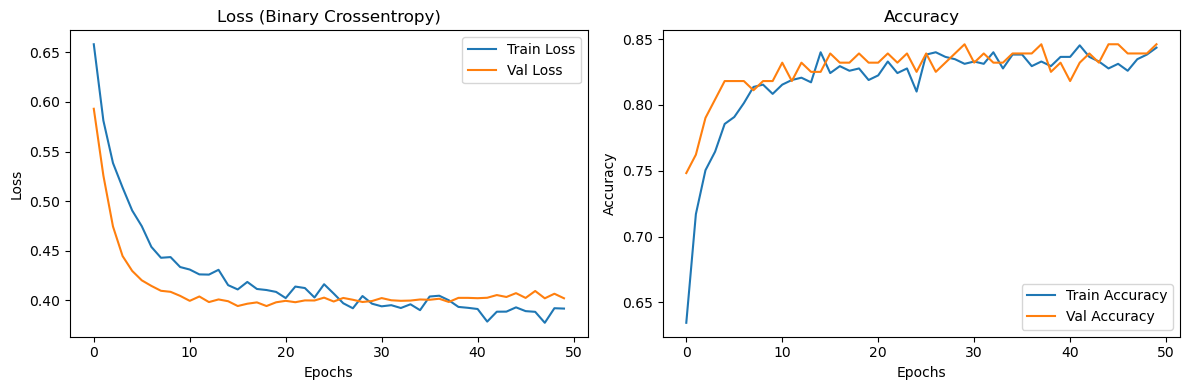

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('http://bit.ly/kaggletrain')

# 2. Data preprocessing
# Fill missing values: Age with median, Embarked with mode, Fare with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Remove columns that are unnecessary or require complex processing for the basic model
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Encode categorical variables (strings) to numbers
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Separate features (X) and target (y, survival status)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (standardize data to mean 0, variance 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Build DNN model
model = Sequential([
    # Use Input object as the first layer to define input shape.
    Input(shape=(X_train.shape[1],)),
    
    # Hidden layer: 64 neurons, ReLU activation function
    Dense(64, activation='relu'),
    
    # Overfitting prevention: randomly turn off 20% of neurons.
    Dropout(0.2), 
    
    # Hidden layer: 32 neurons
    Dense(32, activation='relu'),
    
    # Output layer: 1 neuron with sigmoid for binary classification
    Dense(1, activation='sigmoid') 
])

# 4. Compile model (set training method)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy', # Binary classification loss function
              metrics=['accuracy'])       # Evaluation metric: accuracy

# 5. Train model
history = model.fit(X_train_scaled, y_train,
                    epochs=50,            # Number of iterations over the entire data
                    batch_size=32,        # Amount of data to learn at once
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=0)            # Reduce log output (0: no output)

# 6. Evaluate model
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Visualize training results (Loss and Accuracy)
plt.figure(figsize=(12, 4))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (Binary Crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.9861
Test Loss: 0.0331


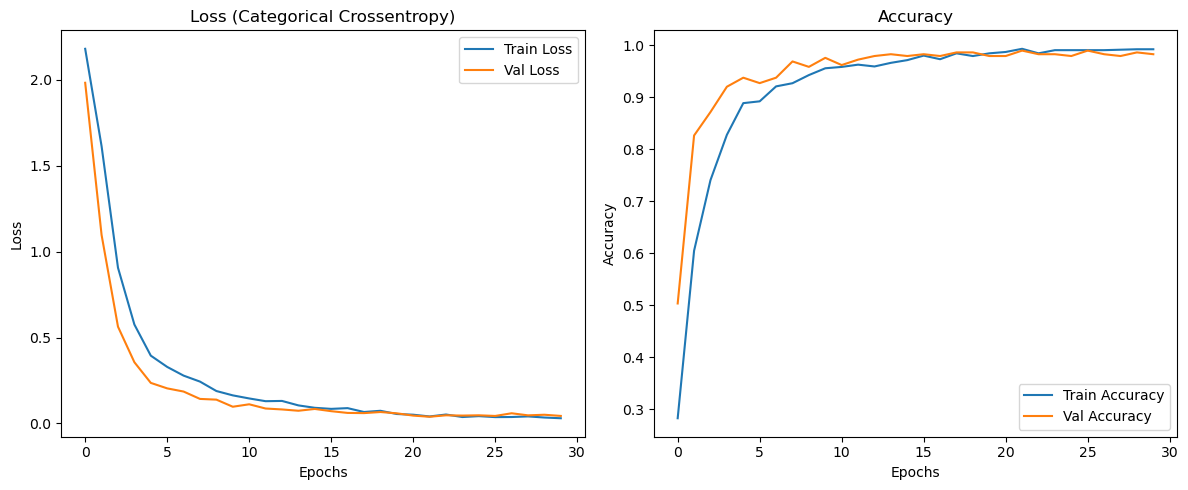

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


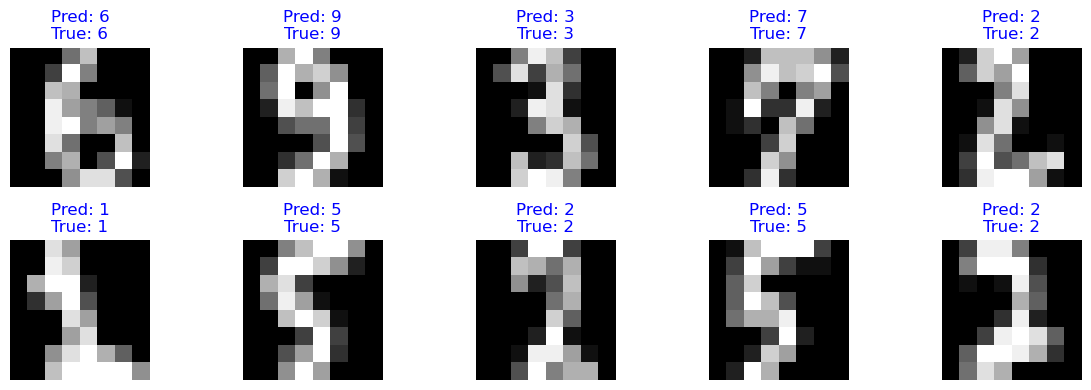

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# 1. Load data
# Uses the built-in handwritten digit dataset (Digits) from scikit-learn.
# A safe and standard example that works without internet connection.
digits = load_digits()
X = digits.images  # Image data of shape (1797, 8, 8)
y = digits.target  # Answer labels (0-9)

# 2. Preprocessing
# Scaling: Convert pixel values (0-16) to range 0-1 for better training efficiency.
X = X / 16.0

# Reshape: CNN requires 4D input of shape (samples, height, width, channels).
# Since these are grayscale images, the channel count is 1.
X = X.reshape(-1, 8, 8, 1)

# One-hot encode answer labels: Convert digits 0-9 to 10 probability values for comparison.
# Example: 2 -> [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = to_categorical(y, num_classes=10)

# Split train/test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Build CNN Model
model = Sequential([
    # Input layer: receives images of shape (8, 8, 1).
    Input(shape=(8, 8, 1)),
    
    # Convolution layer 1: extracts features from the image using 32 filters.
    # padding='same' pads the border with zeros to prevent image size reduction.
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    
    # Pooling layer 1: compresses important information by halving image size (to 4x4).
    MaxPooling2D((2, 2)),
    
    # Convolution layer 2: extracts deeper, more complex features using 64 filters.
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    
    # Pooling layer 2: halves image size again (to 2x2).
    MaxPooling2D((2, 2)),
    
    # Flatten: flattens 2D data to 1D to prepare for DNN (Dense layers).
    Flatten(),
    
    # Hidden layer (Dense): synthesizes extracted features for judgment.
    Dense(64, activation='relu'),
    
    # Overfitting prevention: randomly turn off 30% of neurons.
    Dropout(0.3),
    
    # Output layer: uses softmax to select one of 10 digits.
    Dense(10, activation='softmax')
])

# 4. Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', # Multi-class (>2 classes) loss function
              metrics=['accuracy'])

# 5. Train
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# 6. Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Result visualization 1: Learning curves
plt.figure(figsize=(12, 5))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (Categorical Crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Result visualization 2: Prediction samples
plt.figure(figsize=(12, 4))
predictions = model.predict(X_test[:10]) # Predict 10 test samples

for i in range(10):
    plt.subplot(2, 5, i+1)
    # Convert back to 8x8 image for display
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    
    # Find the index (digit) with the highest probability
    pred_label = np.argmax(predictions[i])
    true_label = np.argmax(y_test[i])
    
    color = 'blue' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()